# Report

**Group name:** Timo & Jakub

**Student names & numbers:**
* Timo Storny - 00099699
* Jakub Holik - 00099393


---

## 0. Iteration setup

**Import libraries**

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import seaborn as sns
import rasterio
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

**Load datasets**

This study uses multiple datasets from reliable scientific and governmental sources. Weather data were obtained from the Royal Netherlands Meteorological Institute (KNMI), including measurements such as temperature, wind, precipitation, and radiation from several coastal stations in the Netherlands. Environmental data were sourced from Statistics Netherlands (CBS), specifically ecosystem type maps covering the period 2013–2022. In addition, species occurrence data for Clupea harengus (Atlantic herring) were retrieved from the Global Biodiversity Information Facility (GBIF), an international open-access biodiversity database.

In [29]:
df_clupea = pd.read_csv('Clupea harengus.csv')
df_weather = pd.read_csv('knmi_weather_data.csv')
df_env = rasterio.open('enviroment.tif')

C:\Users\holik\AppData\Local\Temp\ipykernel_16920\2334837889.py:1: DtypeWarning: Columns (0: Clupea harengus) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clupea = pd.read_csv('Clupea harengus.csv')


In [30]:
df_clupea['eventDate'] = pd.to_datetime(df_clupea['eventDate'], format='%Y-%m-%d')
print("General information:")
df_clupea.info()

print("\n\nAmount of null's in each column:")
print(df_clupea.isnull().sum())

print("\n\nStatistical summary:")
df_clupea.describe()

General information:
<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Clupea harengus            object        
dtypes: datetime64[us](1), float64(3), int64(1), object(1)
memory usage: 574.9+ MB


Amount of null's in each column:
decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           1
speciesgroup_observations    0
Clupea harengus              0
dtype: int64


Statistical summary:


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations
count,1.255879e+07,1.255879e+07,12558786,1.255878e+07,1.255879e+07
mean,5.222995e+01,5.532896e+00,2017-12-31 12:10:06.165595,8.134787e+00,8.965699e-02
min,3.500000e+00,3.350000e+00,2010-01-01 00:00:00,0.000000e+00,0.000000e+00
25%,5.170000e+01,4.900000e+00,2014-01-01 00:00:00,0.000000e+00,0.000000e+00
50%,5.220000e+01,5.650000e+00,2018-01-01 00:00:00,1.000000e+00,0.000000e+00
75%,5.280000e+01,6.200000e+00,2022-01-01 00:00:00,6.000000e+00,0.000000e+00
max,5.350000e+01,5.340000e+01,2026-01-30 00:00:00,1.000400e+05,1.011000e+03
std,6.647267e-01,8.779710e-01,NaN,5.593995e+01,2.514183e+00


In [31]:
str_columns = df_weather.select_dtypes(include=['object', 'string']).columns

for col in str_columns:
    df_weather[col] = pd.to_numeric(df_weather[col], errors='coerce')

df_weather['Date'] = pd.to_datetime(df_weather['Date'], format='%Y%m%d')

df_weather = df_weather.replace(r'^\s*$', pd.NA, regex=True)

print("General information:")
df_weather.info()

print("\n\nAmount of null's in each column:")
print(df_weather.isna().sum())

print("\n\nStatistical summary:")
df_weather.describe()

General information:
<class 'pandas.DataFrame'>
RangeIndex: 71784 entries, 0 to 71783
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Station                        71784 non-null  int64         
 1   Date                           71784 non-null  datetime64[us]
 2   vector_mean_direction_degrees  70421 non-null  float64       
 3   vector_mean_windspeed          70421 non-null  float64       
 4   windspeed                      70514 non-null  float64       
 5   windgust                       70498 non-null  float64       
 6   temp_mean                      35855 non-null  float64       
 7   temp_min                       35855 non-null  float64       
 8   temp_max                       35855 non-null  float64       
 9   sun_dur                        29906 non-null  float64       
 10  per_max_pot_sun_dur            29906 non-null  float64       
 11  globa

,Station,Date,vector_mean_direction_degrees,vector_mean_windspeed,windspeed,windgust,temp_mean,temp_min,temp_max,sun_dur,per_max_pot_sun_dur,global_radiation,precipitation_dur,precipitation,cloud_cover
count,71784.000000,71784,70421.000000,70421.000000,70514.000000,70498.000000,35855.000000,35855.000000,35855.000000,29906.000000,29906.000000,29906.000000,29907.000000,29907.000000,19291.000000
mean,274.750000,2018-03-10 12:00:00,190.671490,59.356769,67.406132,132.244319,109.198857,80.477925,137.794338,53.724069,41.440012,1107.955527,17.106697,22.103454,5.686693
min,209.000000,2010-01-01 00:00:00,1.000000,0.000000,10.000000,30.000000,-114.000000,-176.000000,-67.000000,-1.000000,0.000000,22.000000,0.000000,-1.000000,0.000000
25%,240.250000,2014-02-04 00:00:00,110.000000,36.000000,45.000000,100.000000,67.000000,42.000000,89.000000,14.000000,13.000000,337.250000,0.000000,0.000000,4.000000
50%,281.000000,2018-03-10 12:00:00,210.000000,56.000000,63.000000,120.000000,106.000000,79.000000,135.000000,48.000000,40.000000,935.000000,2.000000,1.000000,6.000000
75%,310.500000,2022-04-14 00:00:00,258.000000,79.000000,85.000000,160.000000,156.000000,125.000000,188.000000,87.000000,68.000000,1770.000000,24.000000,24.000000,8.000000
max,330.000000,2026-05-18 00:00:00,360.000000,202.000000,203.000000,480.000000,303.000000,236.000000,389.000000,157.000000,95.000000,3180.000000,240.000000,780.000000,8.000000
std,39.132793,NaN,95.306002,30.438256,28.593083,47.734481,57.372641,54.645667,64.412893,43.248569,30.372459,838.851918,28.085692,45.114325,2.241838


| Station | LON (east) | LAT (north) | ALT (m) | Name               |
| ------- | ---------- | ----------- | ------- | ------------------ |
| 209     | 4.518      | 52.465      | 0.00    | IJmond             |
| 225     | 4.555      | 52.463      | 4.40    | IJmuiden           |
| 235     | 4.781      | 52.928      | 1.20    | De Kooy Airport    |
| 242     | 4.921      | 53.241      | 10.80   | Vlieland Vliehors  |
| 251     | 5.346      | 53.392      | 0.70    | Hoorn Terschelling |
| 277     | 6.200      | 53.413      | 2.90    | Lauwersoog         |
| 285     | 6.399      | 53.575      | 0.00    | Huibertgat         |
| 308     | 3.379      | 51.381      | 0.00    | Cadzand            |
| 310     | 3.596      | 51.442      | 8.00    | Vlissingen         |
| 312     | 3.622      | 51.768      | 0.00    | Oosterschelde      |
| 313     | 3.242      | 51.505      | 0.00    | Vlakte van De Raan |
| 330     | 4.122      | 51.992      | 11.90   | Hoek van Holland   |

In [44]:
print(f"Width: {df_env.width}, Height: {df_env.height}")
print(f"Coordinate Reference System: {df_env.crs}")

Width: 27000, Height: 32000
Coordinate Reference System: EPSG:28992


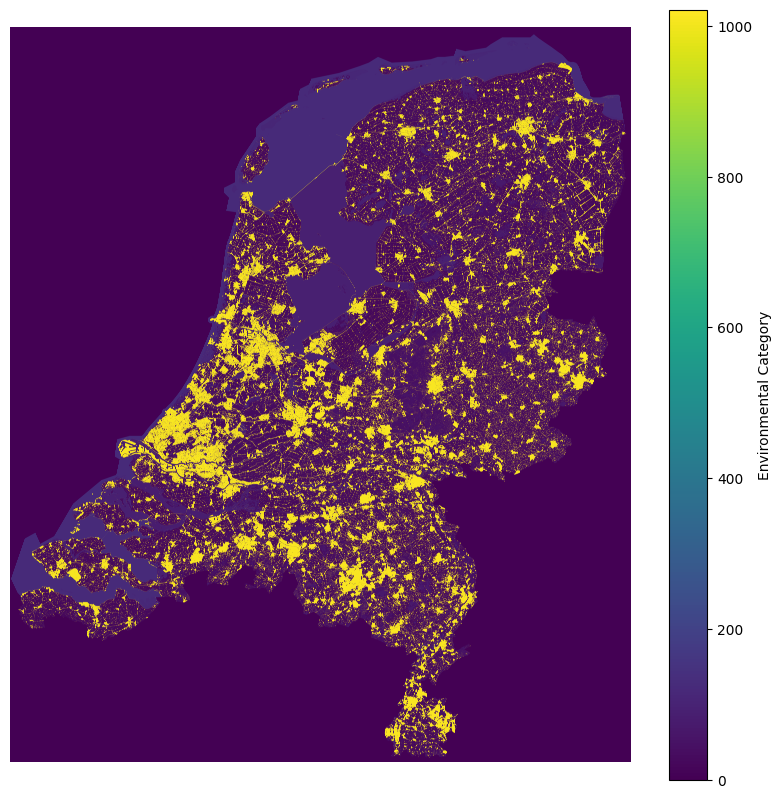

In [ ]:
plt.figure(figsize=(10, 10))

plt.imshow(df_env, cmap='viridis')

plt.colorbar(label="Environmental Category")
plt.axis('off')
plt.show()

---

## 1. Business Understanding (The Ecology / Project Goal)
In an academic data science project using the herring habitat dataset, "business understanding" translates to your ecological objective. 
- **Background:** Briefly explain why modeling the habitat of *Clupea harengus* matters (e.g., understanding spawning grounds, tracking population shifts due to environment, etc.).
- **Problem Statement:** What question are you answering? For example: *"Can we predict the presence or abundance of Atlantic herring based on the percentage of different habitat types (e.g., coastal, water, agricultural) in a given area?"* [exxactcorp](https://www.exxactcorp.com/blog/deep-learning/simple-steps-for-data-preparation-exploratory-data-analysis)
- **Data Management Goals (DMGs):** This is the technical translation of your problem. What exact modeling task will you perform? State whether it is a classification task (e.g., predicting presence vs. absence) or a regression task (e.g., predicting observation counts). Define your target variable and your predictor variables.
- **Success Criteria:** How will you know if your model is "good"? Define the metric you will use (e.g., "Achieve an F1-score above 0.70" or "Beat a baseline logistic regression model by 15% accuracy"). [sites.gatech](https://sites.gatech.edu/omscs7641/2026/01/26/eda-for-cs7641/)

## 2. Initial Exploratory Data Analysis (EDA)
EDA is how you prove you have inspected the data before blindly throwing algorithms at it. You do not need perfect, highly-polished charts yet; the goal is to show you understand the dataset's shape, quality, and patterns. [linkedin](https://www.linkedin.com/pulse/exploratory-data-analysis-eda-visual-guide-before-niaz-chowdhury-phd-2d6qe)

Include the following steps and visuals in your EDA:
- **Data Overview:** Report the shape of your dataset (number of rows and columns) and list the features (e.g., `decimalLongitude`, `decimalLatitude`, `coast`, `forest`, `agricultural`, etc.). [sites.gatech](https://sites.gatech.edu/omscs7641/2026/01/26/eda-for-cs7641/)
- **Data Quality Check:** Show that you have checked for missing values (NaNs), duplicates, and incorrect data types. Mention how you plan to handle any issues you found (e.g., "We will drop 12 rows with missing coordinates"). [linkedin](https://www.linkedin.com/pulse/exploratory-data-analysis-eda-visual-guide-before-niaz-chowdhury-phd-2d6qe)
- **Univariate Analysis (Distributions):** Look at variables one at a time.
  - Plot a histogram or bar chart of your target variable. Is it imbalanced? (e.g., Are there 10,000 "presence" rows but only 500 "absence" rows?)
  - Plot histograms for key predictors (like the percentage of `coast` or `water` habitat). [kaggle](https://www.kaggle.com/questions-and-answers/412077)
- **Bivariate/Multivariate Analysis (Relationships):** Look at how variables interact.
  - Show a correlation heatmap of the numerical features. This will show if variables are highly correlated (e.g., maybe `coast` and `water` are multicollinear and you shouldn't use both). [linkedin](https://www.linkedin.com/pulse/exploratory-data-analysis-eda-visual-guide-before-niaz-chowdhury-phd-2d6qe)
  - Create boxplots or violin plots showing the distribution of specific habitat types split by your target variable (e.g., "Percentage of Coastal Habitat vs. Herring Presence"). [kaggle](https://www.kaggle.com/questions-and-answers/412077)
- **Spatial Plot (Optional but highly recommended):** Since you have coordinates (`decimalLongitude`, `decimalLatitude`), plot your data points on a scatter plot or a map. This is a massive bonus for an ecological dataset and immediately shows if herring are clustering in specific regions.

Finish your check-in with a short **conclusion/next steps** section stating your data is viable and what preprocessing (scaling, imputation, feature engineering) you will do next based on your EDA. 

---

### Data Understanding

In [32]:
df_merged = pd.merge(df_clupea, df_weather, left_on='eventDate', right_on='Date', how='left')
df_merged.head()

MemoryError: Unable to allocate 1.12 GiB for an array with shape (150705432,) and data type int64

In [26]:
# ==========================================
# 2. BOXPLOT: DISTRIBUTIONS & OUTLIERS
# ==========================================
weather_cols = [
    'windspeed',
    'windgust',
    'temp_mean',
    'temp_min',
    'temp_max',
    'precipitation',
    'cloud_cover'
]

df_weather_small = df_weather[weather_cols]

# Sample weather rows
weather_sample = df_weather_small.dropna().sample(
    n=min(5000, len(df_weather_small.dropna())),
    random_state=42
)

# Boxplot
melted = weather_sample.melt(var_name='variable', value_name='value')
plt.figure(figsize=(14, 6))
sns.boxplot(data=melted, x='variable', y='value')
plt.xticks(rotation=45, ha='right')
plt.title('Weather Distributions and Outliers (sampled)')
plt.tight_layout()
plt.show()

KeyError: "None of [Index(['windspeed', 'windgust', 'temp_mean', 'temp_min', 'temp_max',\n       'precipitation', 'cloud_cover'],\n      dtype='str')] are in the [columns]"

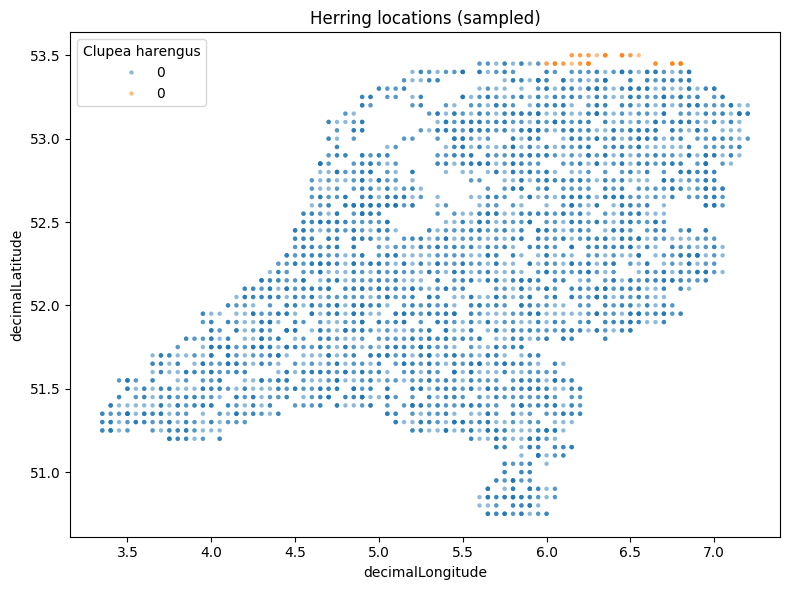

In [23]:
loc_sample = df_clupea[['decimalLongitude', 'decimalLatitude', 'Clupea harengus']].dropna()
loc_sample = loc_sample.sample(n=min(5000, len(loc_sample)), random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=loc_sample, x='decimalLongitude', y='decimalLatitude',
                hue='Clupea harengus', s=10, alpha=0.5, linewidth=0)
plt.title('Herring locations (sampled)')
plt.tight_layout()
plt.show()

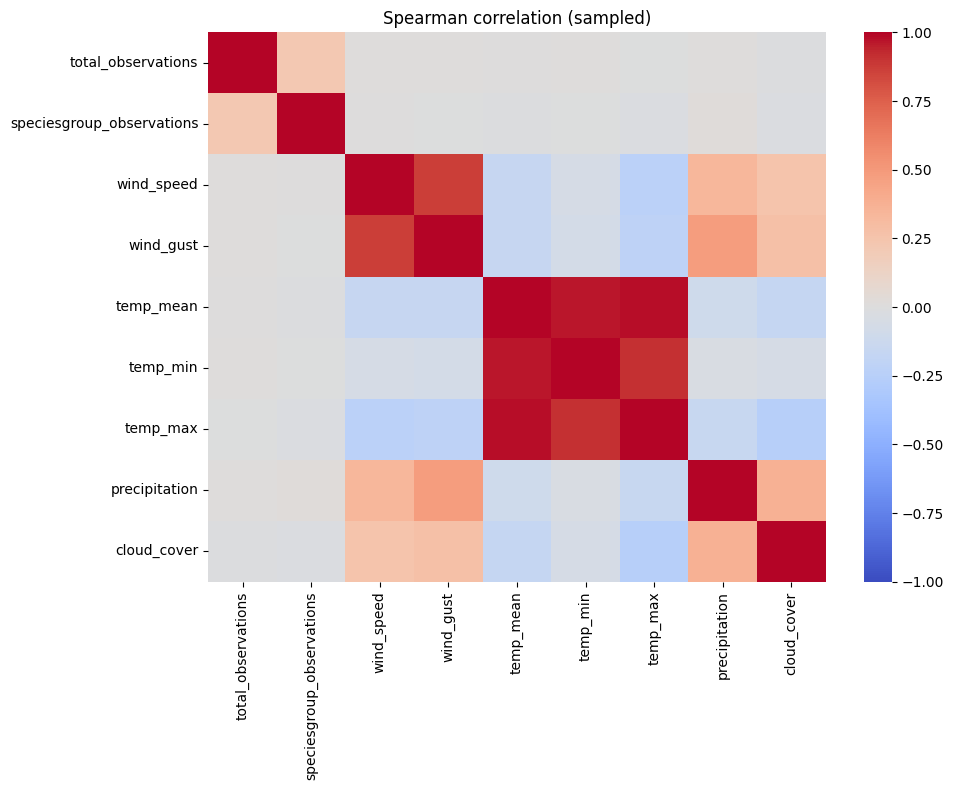

In [24]:
corr_cols = ['total_observations', 'speciesgroup_observations'] + list(weather_map.values())
df_weather_small.columns = list(weather_map.values())

corr_sample = pd.concat([
    df_clupea[['total_observations', 'speciesgroup_observations']].sample(
        n=min(5000, len(df_clupea)), random_state=42
    ).reset_index(drop=True),
    df_weather_small.sample(
        n=min(5000, len(df_weather_small)), random_state=42
    ).reset_index(drop=True)
], axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_sample.corr(method='spearman'), cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman correlation (sampled)')
plt.tight_layout()
plt.show()